<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_Minggu_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Buatlah simulasi deret MA (1) dengan panjang pengamatan 20 dengan nilai parameter $\theta=0.1, \theta=0.3, \theta=0.7, \theta=1.0, \theta=1.5, \theta=2.0$

In [1]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

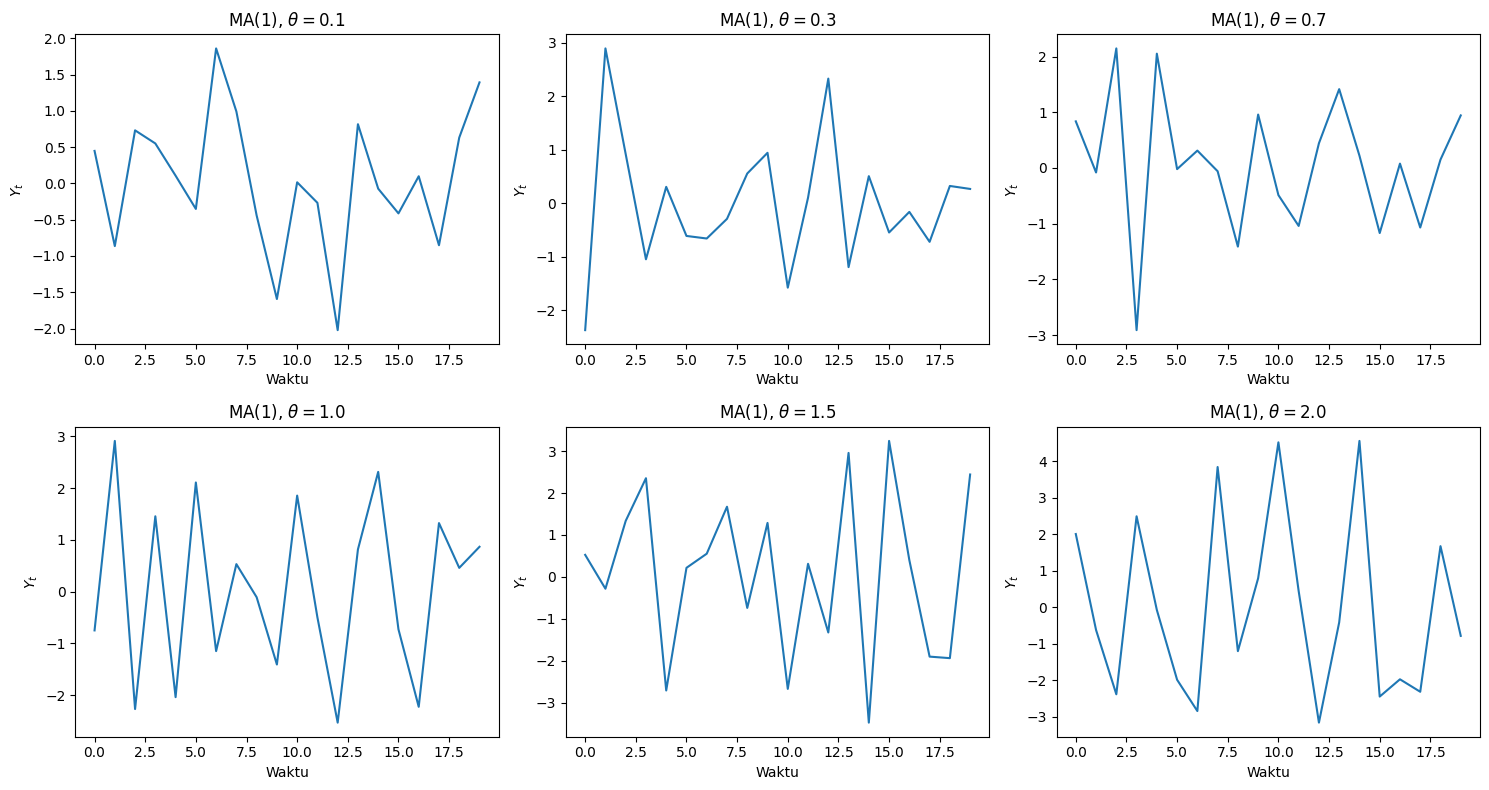

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ma1(theta, n=100):
    """
    Simulasi proses MA(1) berdasarkan formula user:
        Y_t = epsilon_t - theta * epsilon_{t-1}
    dengan:
        epsilon_t ~ Normal(0, 1)
        epsilon_0 diinisialisasi.
    """
    epsilon = [np.random.normal(0, 1)] # Inisialisasi epsilon_0
    ma1_series = []
    for i in range(n):
        epsilon.append(np.random.normal(0, 1)) # epsilon_{i+1}
        ma1_series.append(epsilon[i+1] - theta * epsilon[i])
    return np.array(ma1_series)

# Parameters for MA(1) simulation
theta_list = [0.1, 0.3, 0.7, 1.0, 1.5, 2.0]
n_observations = 20 # Consistent with other simulations in the notebook

# Set random seed as requested by the user
np.random.seed(1302)

# Simulate MA(1) series
ma1_m1 = simulate_ma1(theta_list[0], n=n_observations)
ma1_m2 = simulate_ma1(theta_list[1], n=n_observations)
ma1_m3 = simulate_ma1(theta_list[2], n=n_observations)
ma1_m4 = simulate_ma1(theta_list[3], n=n_observations)
ma1_m5 = simulate_ma1(theta_list[4], n=n_observations)
ma1_m6 = simulate_ma1(theta_list[5], n=n_observations)

# Original plotting code
# theta_list is redefined here to ensure it aligns with the simulation
theta_list = [0.1, 0.3, 0.7, 1.0, 1.5, 2.0]
data_ma = [ma1_m1, ma1_m2, ma1_m3, ma1_m4, ma1_m5, ma1_m6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, data, theta in zip(axes.flatten(), data_ma, theta_list):
    ax.plot(data)
    ax.set_title(rf'MA(1), $\theta={theta}$')
    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')

plt.tight_layout()
plt.show()

### 2. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 1 dan bandingkan. Berdasarkan plot ACF tersebut, apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 pada model MA(1)? (Hint: Identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA, kaitkan nilai autokorelasi sampel dengan nilai autokorelasi MA(1) secara teori.)

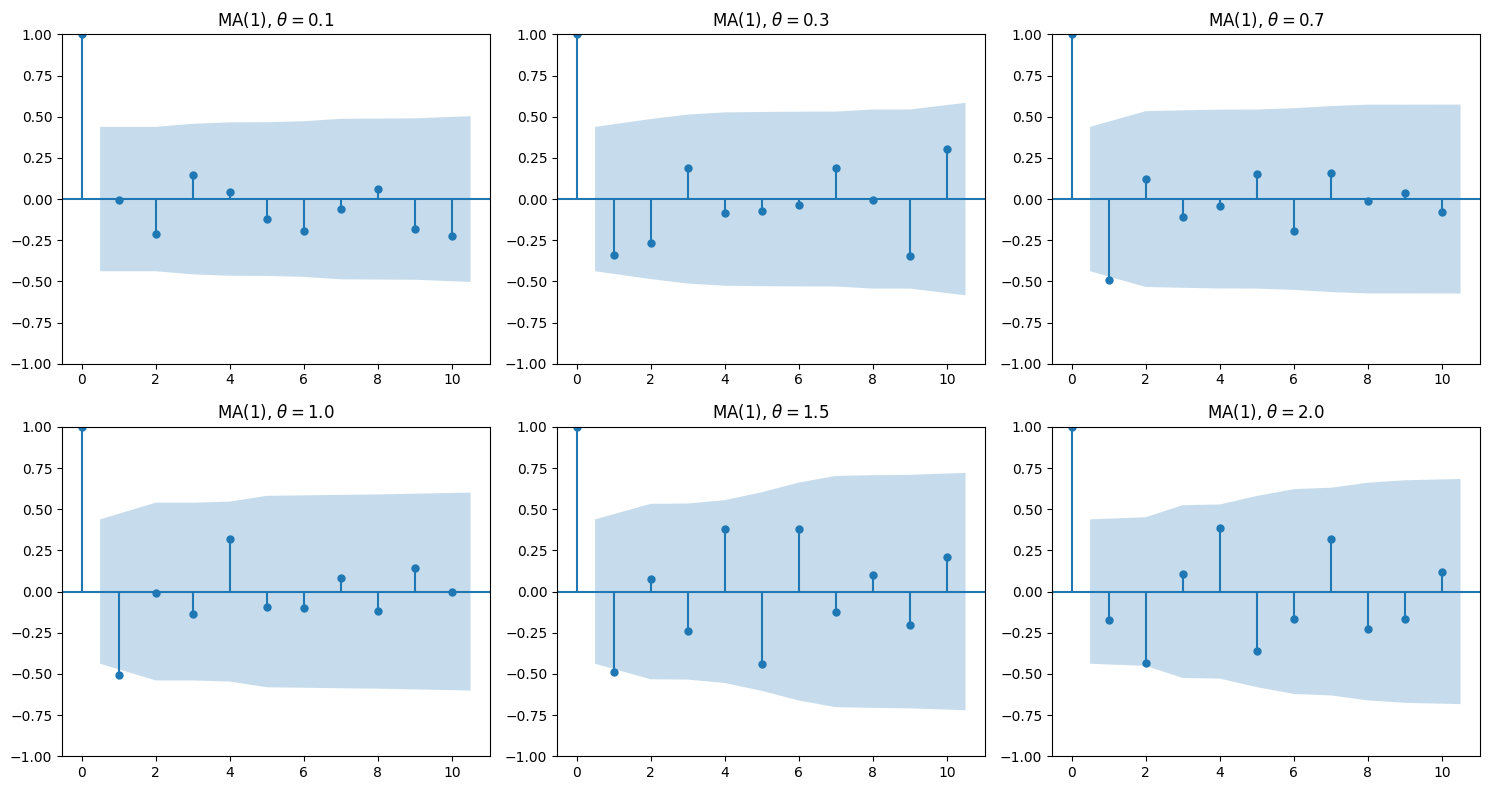

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_acf(ma1_m1, ax=axes[0,0], lags=10, title=r'MA(1), $\theta=0.1$')
plot_acf(ma1_m2, ax=axes[0,1], lags=10, title=r'MA(1), $\theta=0.3$')
plot_acf(ma1_m3, ax=axes[0,2], lags=10, title=r'MA(1), $\theta=0.7$')

plot_acf(ma1_m4, ax=axes[1,0], lags=10, title=r'MA(1), $\theta=1.0$')
plot_acf(ma1_m5, ax=axes[1,1], lags=10, title=r'MA(1), $\theta=1.5$')
plot_acf(ma1_m6, ax=axes[1,2], lags=10, title=r'MA(1), $\theta=2.0$')

plt.tight_layout()
plt.show()

### 3. Buatlah simulasi deret MA (1) dengan parameter $\theta=0.25$ dengan panjang pengamatan 60, 100,150, 300.


In [10]:
# Parameters for MA(1) simulation (theta=0.25)
theta_ma7_to_ma10 = 0.25
n_observations_list = [60, 100, 150, 300]

# Set random seed as requested by the user
np.random.seed(120)

# Simulate MA(1) series for different lengths
ma1_m7 = simulate_ma1(theta_ma7_to_ma10, n=n_observations_list[0])
ma1_m8 = simulate_ma1(theta_ma7_to_ma10, n=n_observations_list[1])
ma1_m9 = simulate_ma1(theta_ma7_to_ma10, n=n_observations_list[2])
ma1_m10 = simulate_ma1(theta_ma7_to_ma10, n=n_observations_list[3])

4. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 3 dan bandingkan. Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 pada model MA(1)? (Hint: Identifikasi pola interval kepercayaan dari nilai autokorelasi berdasarkan panjang observasi.)

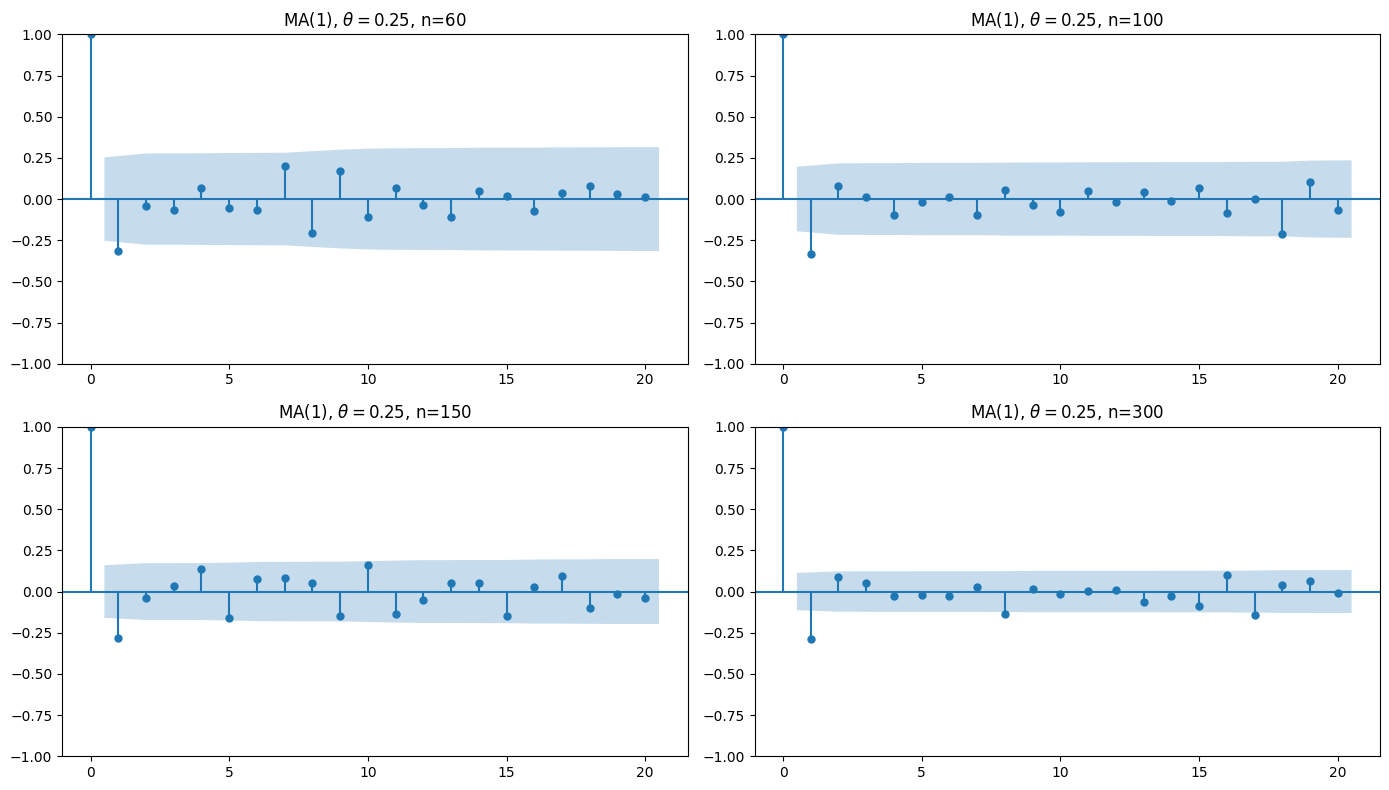

In [11]:
data_ma = [ma1_m7, ma1_m8, ma1_m9, ma1_m10]
n_list = [60, 100, 150, 300]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, data, n in zip(axes.flatten(), data_ma, n_list):
    plot_acf(data, ax=ax, lags=20,
             title=rf'MA(1), $\theta=0.25$, n={n}')

plt.tight_layout()
plt.show()

5. Buatlah simulasi deret MA (2) dengan panjang pengamatan 50 dengan parameter:
   
   a. $\theta_1=0.3, \theta_2=0.8$
   
   b. $\theta_1=-0.3, \theta_2=0.8$
   
   c. $\theta_1=0.3, \theta_2=-0.8$
   
   d. $\theta_1=-0.3, \theta_2=-0.8$


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [20]:
THETA1A = 0.3
THETA2A = 0.8
THETA1B = -0.3
THETA2B = 0.8
THETA1C = 0.3
THETA2C = -0.8
THETA1D = -0.3
THETA2D = -0.8
NSAMPLE = 50

In [21]:
SUMLAST2DIGIT = 33+50+37
print(SUMLAST2DIGIT)

120


In [22]:
def generate_ma2_sample(theta1, theta2, nsample):
  np.random.seed(SUMLAST2DIGIT)
  ar = np.array([1])
  ma2 = np.array([1, -theta1, -theta2])
  ma2_obj = ArmaProcess(ar, ma2)
  ma2_sample = ma2_obj.generate_sample(nsample=nsample)
  return ma2_sample

In [23]:
data_a = generate_ma2_sample(THETA1A, THETA2A, NSAMPLE)
data_b = generate_ma2_sample(THETA1B, THETA2B, NSAMPLE)
data_c = generate_ma2_sample(THETA1C, THETA2C, NSAMPLE)
data_d = generate_ma2_sample(THETA1D, THETA2D, NSAMPLE)

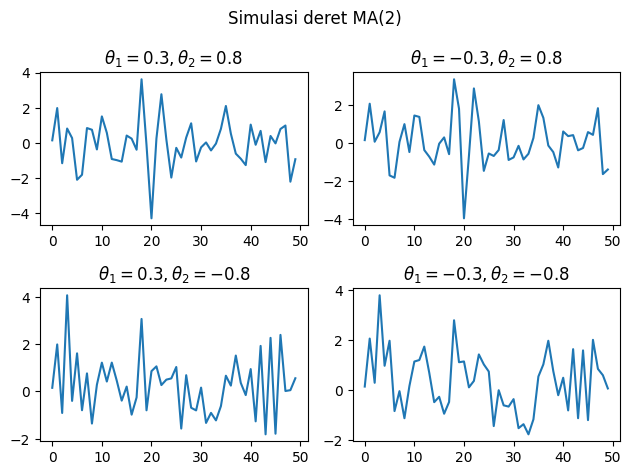

In [24]:
fig, axs = plt.subplots(2,2)
fig.suptitle('Simulasi deret MA(2)')
axs[0,0].plot(data_a)
axs[0,0].set_title(r'$\theta_1=0.3, \theta_2=0.8$')
axs[0,1].plot(data_b)
axs[0,1].set_title(r'$\theta_1=-0.3, \theta_2=0.8$')
axs[1,0].plot(data_c)
axs[1,0].set_title(r'$\theta_1=0.3, \theta_2=-0.8$')
axs[1,1].plot(data_d)
axs[1,1].set_title(r'$\theta_1=-0.3, \theta_2=-0.8$')
plt.tight_layout()
plt.show()

6. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 5 dan bandingkan. Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 dan 2 dari deret MA(2)? (Hint: Identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA.)

In [26]:
def plot_acf_and_lag_scatter(data, lags_for_scatter, title_prefix, acf_lags=10):
    num_scatter_lags = len(lags_for_scatter)
    num_plots = 1 + num_scatter_lags # 1 for ACF, rest for scatter

    fig, axs = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
    if num_plots == 1:
        axs = [axs] # Ensure axs is iterable even for a single subplot

    fig.suptitle(title_prefix)

    # Plot ACF in the first subplot
    plot_acf(data, ax=axs[0], lags=acf_lags)
    axs[0].set_title('ACF')
    axs[0].set_xlabel('Lag')
    axs[0].set_ylabel('Autocorrelation')

    # Plot lag scatters in the remaining subplots
    for i, lag in enumerate(lags_for_scatter):
        pd.plotting.lag_plot(pd.DataFrame(data), lag=lag, c='k', ax=axs[i+1])
        axs[i+1].set_title(f'Lag {lag}')
        axs[i+1].set_xlabel(f'$Y_{{t-{lag}}}$')
        axs[i+1].set_ylabel('$Y_t$')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
    plt.show()


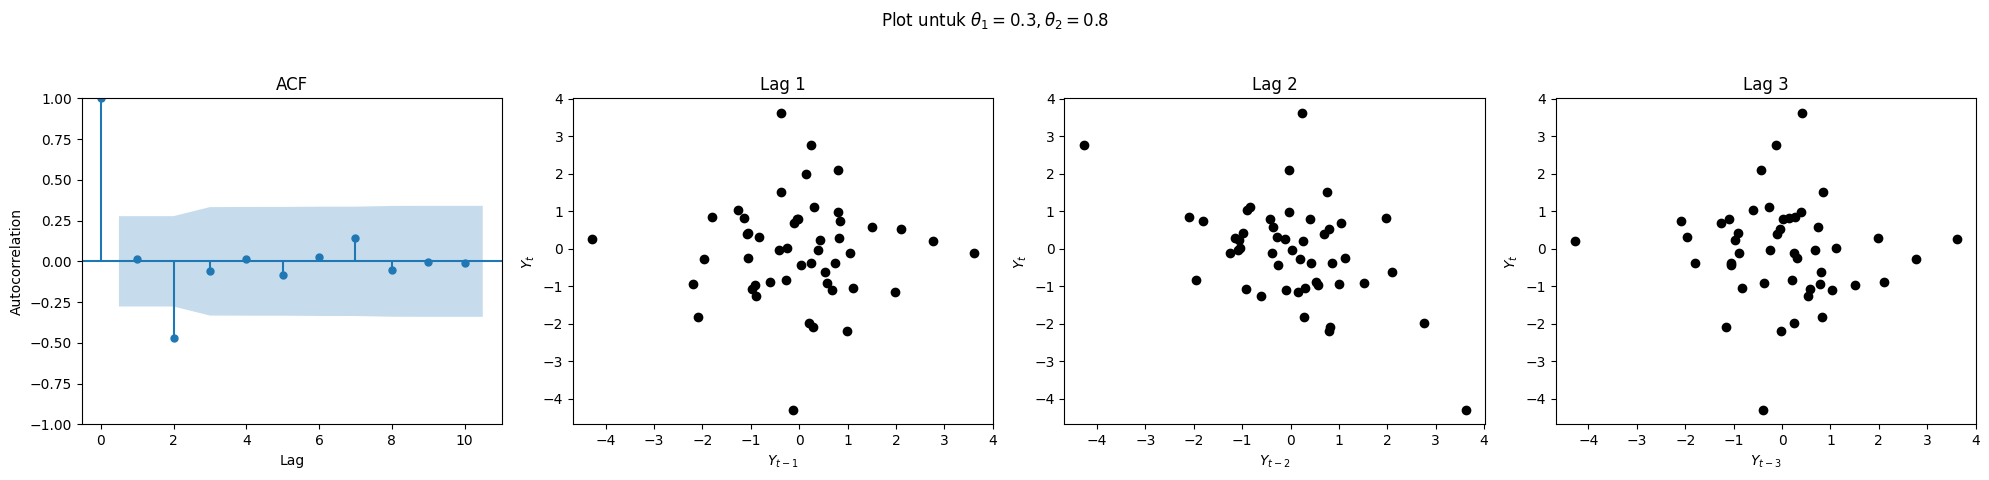

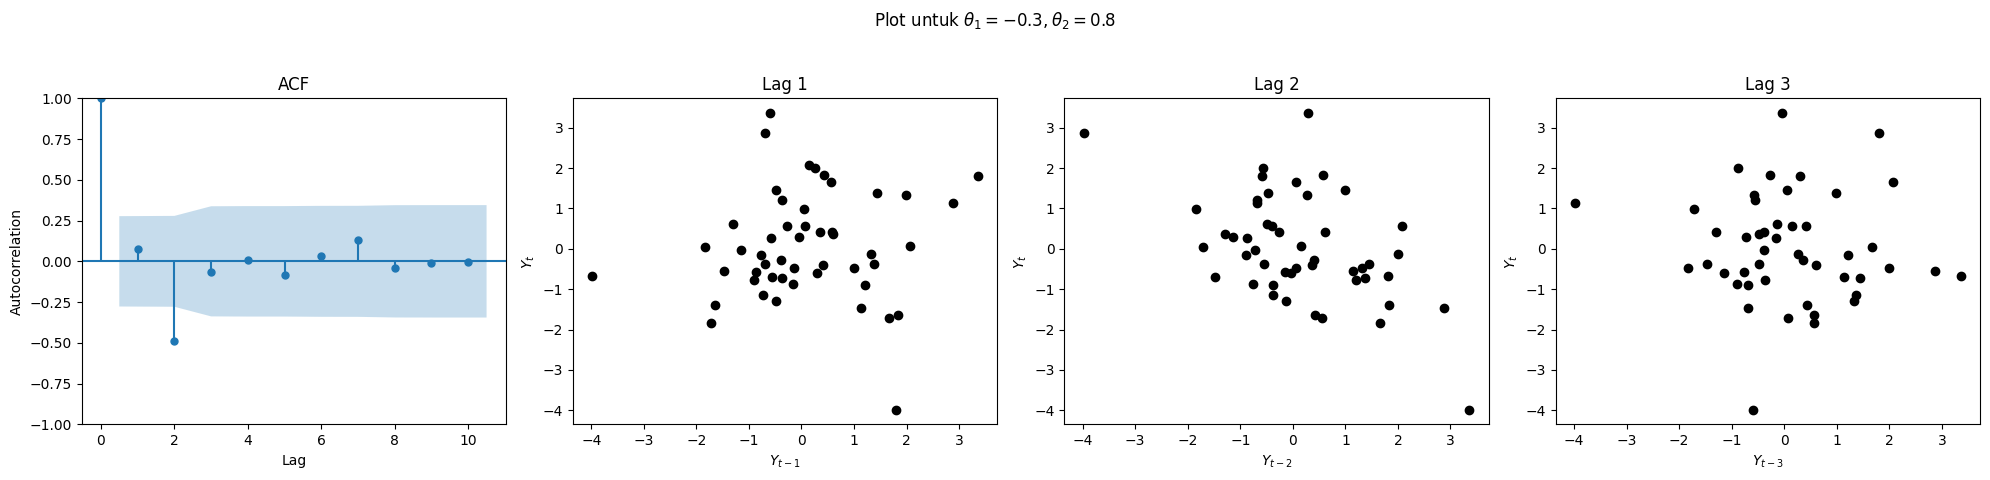

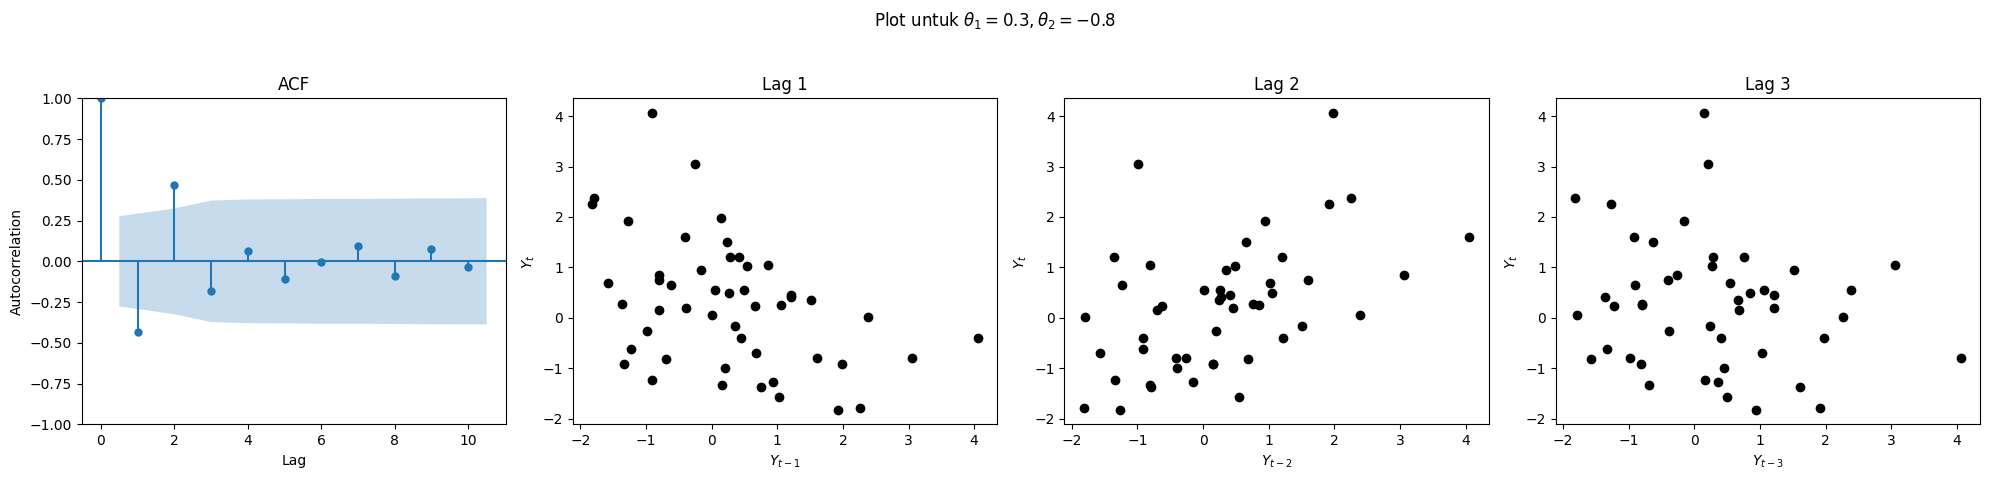

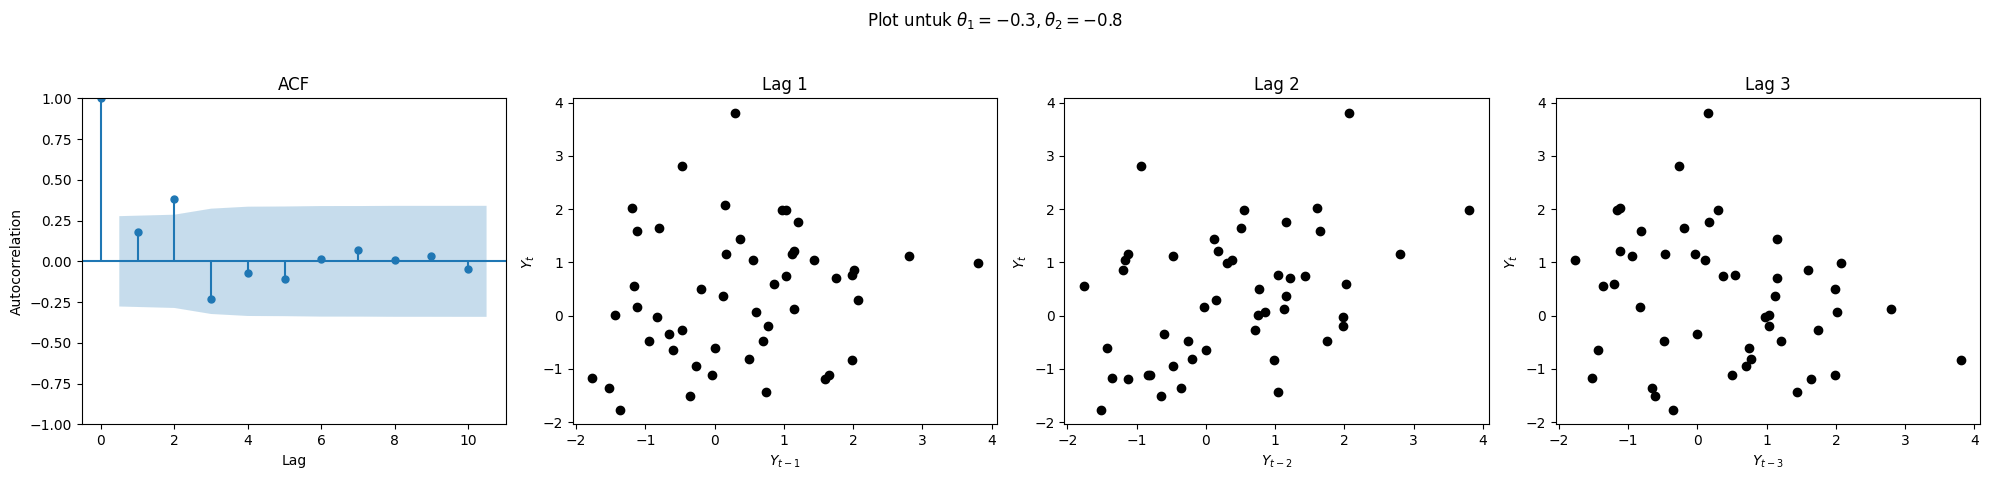

In [27]:
lags_for_scatter = [1, 2, 3]

plot_acf_and_lag_scatter(data_a, lags_for_scatter, r'Plot untuk $\theta_1=0.3, \theta_2=0.8$')
plot_acf_and_lag_scatter(data_b, lags_for_scatter, r'Plot untuk $\theta_1=-0.3, \theta_2=0.8$')
plot_acf_and_lag_scatter(data_c, lags_for_scatter, r'Plot untuk $\theta_1=0.3, \theta_2=-0.8$')
plot_acf_and_lag_scatter(data_d, lags_for_scatter, r'Plot untuk $\theta_1=-0.3, \theta_2=-0.8$')

<h1>Interpretasi plot</h1>
Sesuai dengan persamaan $Y_t = e_t-\theta_1 e_{t-1} - \theta_2 e_{t-2}$ yang memiliki ordo 2, autokorelasi selalu signifikan pada $lag=2$ yang berarti nilai $Y_t$ dipengaruhi kuat oleh $e_{t-1}$ dan $e_{t-2}$. Begitu juga dengan nilai $\rho_2$ ($Autokorelasi$ untuk $lag=2$) yang selalu memiliki arah yang berlawanan terhadap $\theta$, selaras dengan persamaan $\rho_2 = \frac{-\theta_2}{1+\theta^2_1+\theta^2_2}$.


7. Buatlah simulasi deret AR (1) 100 pengamatan dengan nilai parameter $\phi=0.3, \phi=0.9, \phi=-0.3, \phi=-0.9$

In [29]:
# ============================================================
# SIMULASI DAN ANALISIS AR(1)
# phi = 0.3, 0.9, -0.3, -0.9
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


# ============================================================
# 1. FUNGSI SIMULASI AR(1)
# ============================================================

def simulate_ar1(phi, n=100, sigma=1):
    """
    Simulasi proses AR(1) berdasarkan formula user:
        Y_t = phi * Y_(t-1) + epsilon_t
    dengan:
        Y_0 ~ Uniform(0,1)
        epsilon_t ~ Normal(0, sigma^2)
    """

    y = [np.random.uniform(0, 1)]  # Inisialisasi Y_0

    # Proses AR(1)
    for i in range(n - 1): # Loop n-1 kali untuk mendapatkan total n observasi
        y.append(phi * y[i] + np.random.normal(0, sigma))

    return np.array(y)


# ============================================================
# 2. PARAMETER DAN SEED
# ============================================================

np.random.seed(1323) # Updated seed as per user's request

phis = [0.3, 0.9, -0.3, -0.9]

n = 100
sigma = 1


# ============================================================
# 3. SIMULASI DATA HANYA SATU KALI
# ============================================================

series = {}

for phi in phis:

    series[phi] = simulate_ar1(
        phi=phi,
        n=n,
        sigma=sigma
    )


# ============================================================
# 4. MEMBUAT DATAFRAME HASIL SIMULASI
# ============================================================

df_simulasi = pd.DataFrame({
    f'Y_phi_{phi}': series[phi]
    for phi in phis
})

df_simulasi.index = np.arange(1, n + 1)
df_simulasi.index.name = 'Waktu'


print("DATA SIMULASI AR(1)")
print("=" * 70)

display(df_simulasi.head(10))


DATA SIMULASI AR(1)


,Y_phi_0.3,Y_phi_0.9,Y_phi_-0.3,Y_phi_-0.9
Waktu,,,,
1,0.199814,0.536394,0.308743,0.109738
2,-0.183725,0.059087,1.112546,-0.333065
3,-1.913389,0.233550,-0.528409,-0.060867
4,-0.930358,0.403904,-1.154061,-0.792460
5,1.513651,1.159657,1.414799,1.151313
6,-0.642585,-0.043077,-0.742110,-0.950408
7,-0.759730,1.504681,-1.146217,0.413939
8,0.427944,1.555918,-0.042834,-0.952260
9,-1.168111,1.944202,0.951021,2.559115


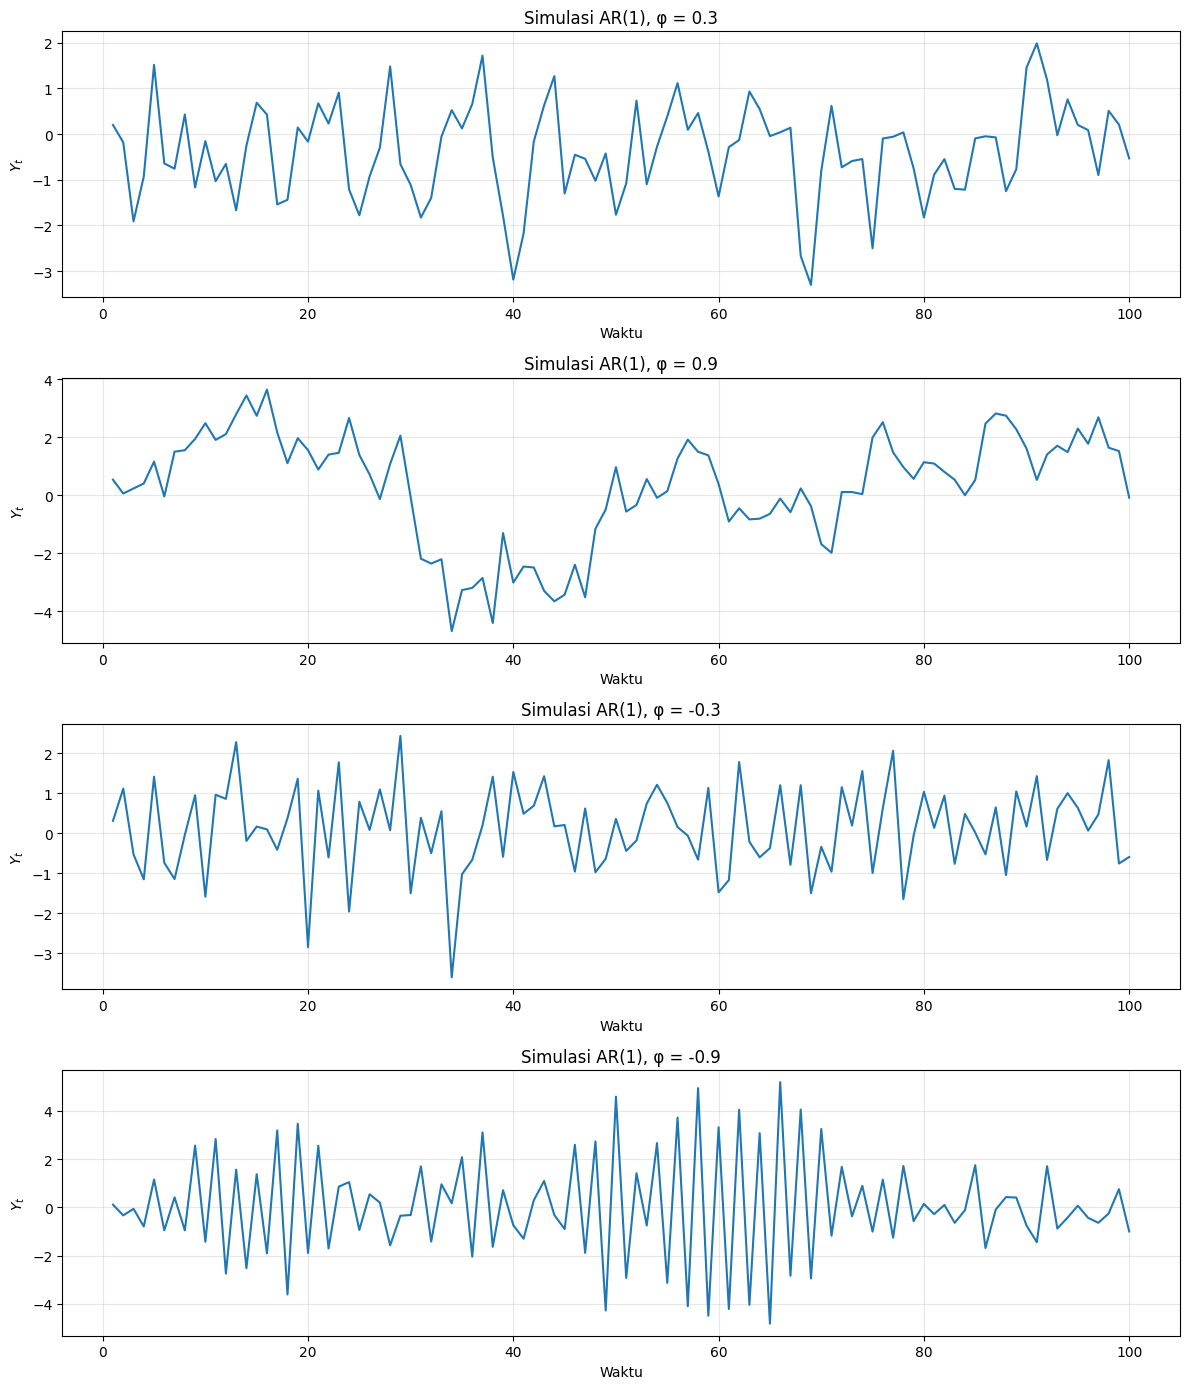

In [30]:

# ============================================================
# 5. PLOT DERET WAKTU
# ============================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 14)
)

for ax, phi in zip(axes, phis):

    y = series[phi]

    ax.plot(
        range(1, n + 1),
        y
    )

    ax.set_title(
        f'Simulasi AR(1), φ = {phi}'
    )

    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()




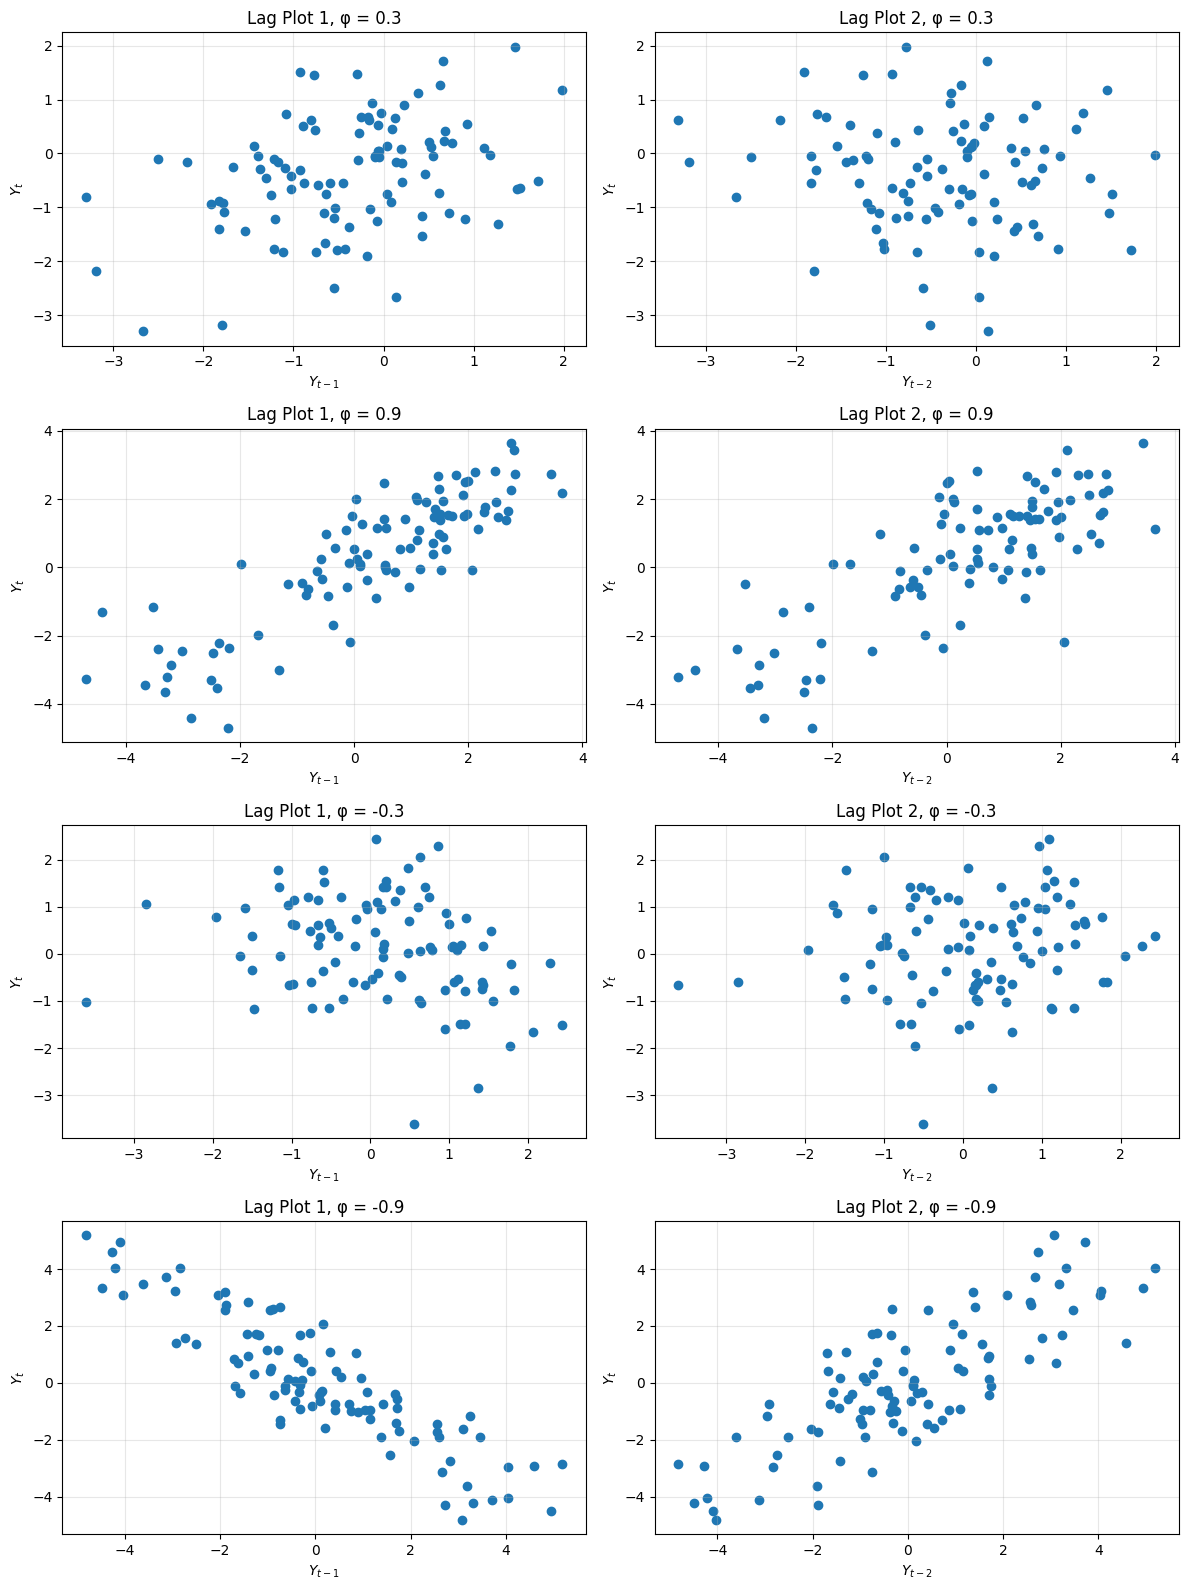

In [31]:
# ============================================================
# 6. LAG PLOT LAG 1 DAN LAG 2
# ============================================================

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

for i, phi in enumerate(phis):

    y = series[phi]

    # -----------------------------
    # Lag 1
    # -----------------------------

    axes[i, 0].scatter(
        y[:-1],
        y[1:]
    )

    axes[i, 0].set_title(
        f'Lag Plot 1, φ = {phi}'
    )

    axes[i, 0].set_xlabel(
        r'$Y_{t-1}$'
    )

    axes[i, 0].set_ylabel(
        r'$Y_t$'
    )

    axes[i, 0].grid(alpha=0.3)


    # -----------------------------
    # Lag 2
    # -----------------------------

    axes[i, 1].scatter(
        y[:-2],
        y[2:]
    )

    axes[i, 1].set_title(
        f'Lag Plot 2, φ = {phi}'
    )

    axes[i, 1].set_xlabel(
        r'$Y_{t-2}$'
    )

    axes[i, 1].set_ylabel(
        r'$Y_t$'
    )

    axes[i, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()




8. Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 7 dan bandingkan. Berdasarkan plot ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada deret AR(1)? (Hint: Identifikasi pola nilai autokorelasi ataupun autokorelasi parsial berdasarkan nilai parameter AR.)

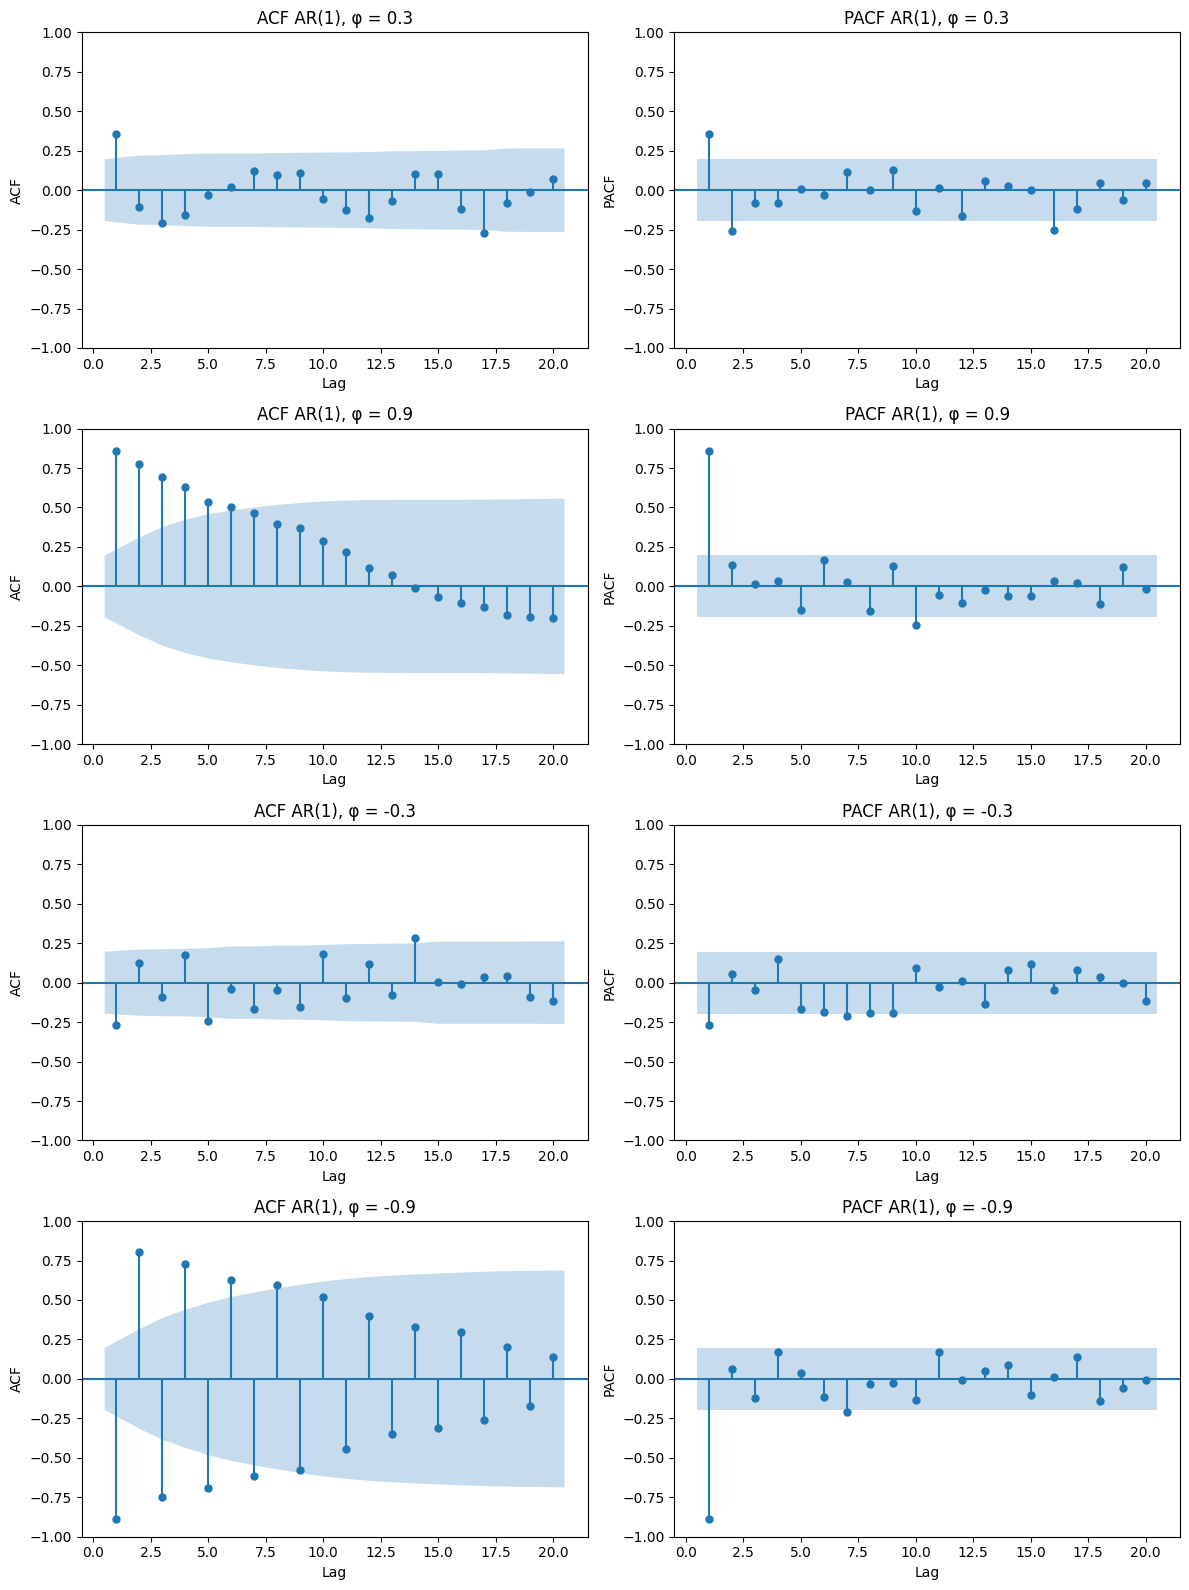

HASIL ACF DAN PACF


,Phi,Lag,ACF_Simulasi,ACF_Teoritis,PACF_Simulasi,Selisih_ACF
0,0.3,1,0.3535,0.3000,0.3535,0.0535
1,0.3,2,-0.1038,0.0900,-0.2615,-0.1938
2,0.3,3,-0.2052,0.0270,-0.0815,-0.2322
3,0.3,4,-0.1589,0.0081,-0.0819,-0.1670
4,0.3,5,-0.0323,0.0024,0.0102,-0.0347
...,...,...,...,...,...,...
75,-0.9,16,0.2987,0.1853,0.0128,0.1134
76,-0.9,17,-0.2616,-0.1668,0.1371,-0.0949
77,-0.9,18,0.2013,0.1501,-0.1423,0.0512
78,-0.9,19,-0.1722,-0.1351,-0.0602,-0.0371


AR(1), φ = 0.3
Koefisien AR(1) estimasi : 0.4334
Koefisien AR(1) teoritis : 0.3000
AR(1), φ = 0.9
Koefisien AR(1) estimasi : 0.8622
Koefisien AR(1) teoritis : 0.9000
AR(1), φ = -0.3
Koefisien AR(1) estimasi : -0.2532
Koefisien AR(1) teoritis : -0.3000
AR(1), φ = -0.9
Koefisien AR(1) estimasi : -0.8890
Koefisien AR(1) teoritis : -0.9000
HASIL UJI LJUNG-BOX


,Phi,Lag,lb_stat,lb_pvalue
0,0.3,1,0.1355,0.7128
1,0.3,2,4.4053,0.1105
2,0.3,3,6.7298,0.0810
3,0.3,4,8.0202,0.0908
4,0.3,5,8.1188,0.1498
...,...,...,...,...
75,-0.9,16,20.8019,0.1863
76,-0.9,17,22.6062,0.1625
77,-0.9,18,24.6139,0.1359
78,-0.9,19,24.7905,0.1676


KEPUTUSAN UJI LJUNG-BOX


...

LAG DENGAN p-value < 0.05

φ = 0.3


,Lag,lb_stat,lb_pvalue
16,17,27.606883,0.049747



φ = 0.9
Tidak terdapat autokorelasi residual yang signifikan pada lag 1-20.

φ = -0.3


,Lag,lb_stat,lb_pvalue
6,7,15.172560,0.033850
7,8,17.430213,0.025928
8,9,19.686130,0.019951
9,10,21.849723,0.015889
10,11,21.942810,0.024820
11,12,22.718289,0.030215
12,13,22.743525,0.044859
13,14,33.595686,0.002362
14,15,34.269893,0.003120
15,16,34.270317,0.004995



φ = -0.9
Tidak terdapat autokorelasi residual yang signifikan pada lag 1-20.


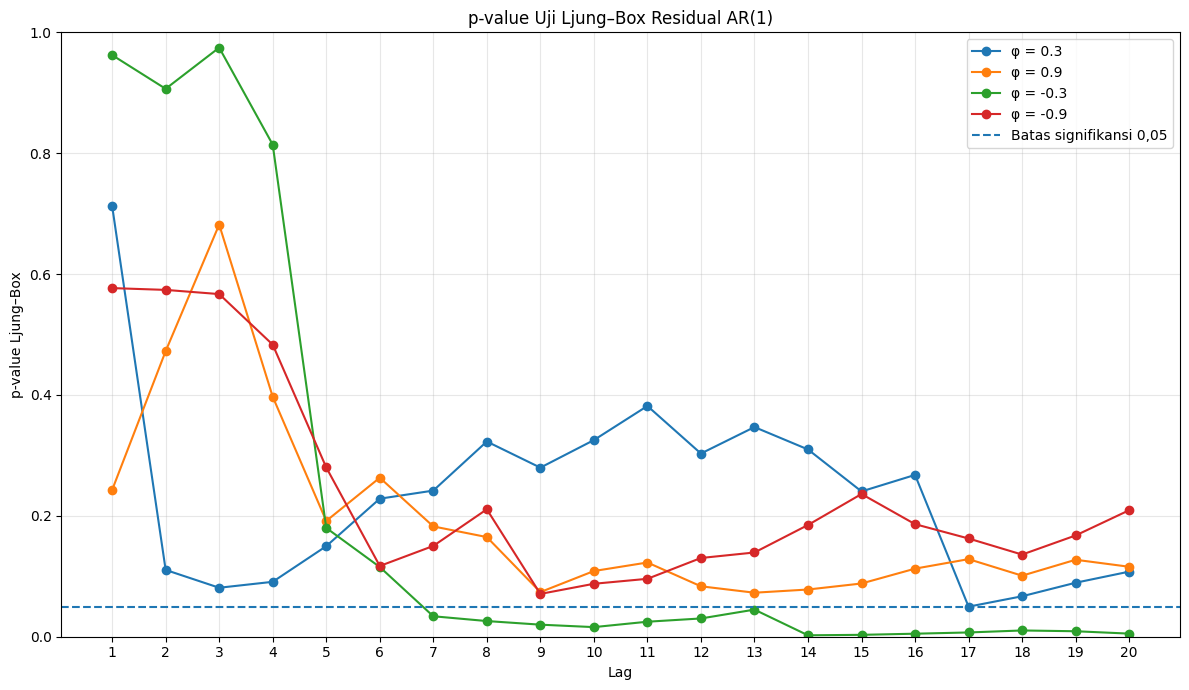

In [32]:
# ============================================================
# 7. PLOT ACF DAN PACF
# ============================================================

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

for i, phi in enumerate(phis):

    y = series[phi]

    # -----------------------------
    # ACF
    # -----------------------------

    plot_acf(
        y,
        lags=20,
        zero=False,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f'ACF AR(1), φ = {phi}'
    )

    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('ACF')


    # -----------------------------
    # PACF
    # -----------------------------

    plot_pacf(
        y,
        lags=20,
        zero=False,
        method='ywm',
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(
        f'PACF AR(1), φ = {phi}'
    )

    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('PACF')


plt.tight_layout()
plt.show()


# ============================================================
# 8. TABEL ACF DAN PACF
# ============================================================

lags = 20

hasil_acf_pacf = []

for phi in phis:

    y = series[phi]

    acf_values = acf(
        y,
        nlags=lags,
        fft=False
    )

    pacf_values = pacf(
        y,
        nlags=lags,
        method='ywm'
    )

    for lag in range(1, lags + 1):

        hasil_acf_pacf.append({

            'Phi': phi,

            'Lag': lag,

            'ACF_Simulasi':
                acf_values[lag],

            'ACF_Teoritis':
                phi ** lag,

            'PACF_Simulasi':
                pacf_values[lag],

            'Selisih_ACF':
                acf_values[lag] - phi ** lag
        })


df_acf_pacf = pd.DataFrame(
    hasil_acf_pacf
)

df_acf_pacf = df_acf_pacf.round(4)


print("HASIL ACF DAN PACF")
print("=" * 70)

display(df_acf_pacf)


# ============================================================
# 9. ESTIMASI AR(1) DAN RESIDUAL
# ============================================================

hasil_model = {}

for phi in phis:

    y = series[phi]

    model = AutoReg(
        y,
        lags=1,
        trend='n',
        old_names=False
    ).fit()

    residual = model.resid

    hasil_model[phi] = {
        'model': model,
        'residual': residual
    }

    print("=" * 70)
    print(f"AR(1), φ = {phi}")
    print("=" * 70)

    print(
        f"Koefisien AR(1) estimasi : "
        f"{model.params[0]:.4f}"
    )

    print(
        f"Koefisien AR(1) teoritis : "
        f"{phi:.4f}"
    )


# ============================================================
# 10. UJI LJUNG-BOX LAG 1-20
# ============================================================

hasil_ljungbox = {}

for phi in phis:

    residual = hasil_model[phi]['residual']

    lb = acorr_ljungbox(
        residual,
        lags=range(1, 21),
        return_df=True
    )

    # Jadikan lag sebagai kolom
    lb = lb.reset_index()

    # Pastikan nama kolom lag
    lb = lb.rename(
        columns={'index': 'Lag'}
    )

    # Tambahkan phi
    lb['Phi'] = phi

    # Susun kolom
    lb = lb[
        [
            'Phi',
            'Lag',
            'lb_stat',
            'lb_pvalue'
        ]
    ]

    hasil_ljungbox[phi] = lb


# ============================================================
# 11. GABUNGKAN HASIL LJUNG-BOX
# ============================================================

df_ljungbox = pd.concat(
    hasil_ljungbox.values(),
    ignore_index=True
)

df_ljungbox = df_ljungbox.round(4)


print("=" * 70)
print("HASIL UJI LJUNG-BOX")
print("=" * 70)

display(df_ljungbox)


# ============================================================
# 12. TABEL KEPUTUSAN LJUNG-BOX
# ============================================================

alpha = 0.05

df_ljungbox['Keputusan'] = np.where(
    df_ljungbox['lb_pvalue'] < alpha,
    'Tolak H0',
    'Gagal menolak H0'
)

df_ljungbox['Keterangan'] = np.where(
    df_ljungbox['lb_pvalue'] < alpha,
    'Ada autokorelasi residual',
    'Tidak ada bukti autokorelasi residual'
)


print("=" * 70)
print("KEPUTUSAN UJI LJUNG-BOX")
print("=" * 70)

display(df_ljungbox)


# ============================================================
# 13. MENAMPILKAN HANYA LAG YANG SIGNIFIKAN
# ============================================================

print("=" * 70)
print("LAG DENGAN p-value < 0.05")
print("=" * 70)

for phi in phis:

    lb = hasil_ljungbox[phi]

    signifikan = lb[
        lb['lb_pvalue'] < alpha
    ]

    print(f"\nφ = {phi}")

    if len(signifikan) == 0:

        print(
            "Tidak terdapat autokorelasi residual "
            "yang signifikan pada lag 1-20."
        )

    else:

        display(
            signifikan[
                [
                    'Lag',
                    'lb_stat',
                    'lb_pvalue'
                ]
            ]
        )


# ============================================================
# 14. PLOT p-value LJUNG-BOX
# ============================================================

plt.figure(figsize=(12, 7))

for phi in phis:

    lb = hasil_ljungbox[phi]

    plt.plot(
        lb['Lag'],
        lb['lb_pvalue'],
        marker='o',
        label=f'φ = {phi}'
    )


# Garis batas signifikansi
plt.axhline(
    y=0.05,
    linestyle='--',
    label='Batas signifikansi 0,05'
)

plt.xlabel('Lag')
plt.ylabel('p-value Ljung–Box')

plt.title(
    'p-value Uji Ljung–Box Residual AR(1)'
)

plt.xticks(
    range(1, 21)
)

plt.ylim(
    0,
    1
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

9. Berdasarkan plot ACF dan PACF pada nomor 8, model apa yang disarankan untuk masing-masing deret? Jelaskan jawaban Anda.

Berdasarkan plot ACF dan PACF, keempat deret menunjukkan karakteristik model AR(1). ACF pada masing-masing deret mengalami tailing off, sedangkan PACF menunjukkan cut-off setelah lag 1. Oleh karena itu, model yang disarankan untuk adalah AR(1). Nilai positif pada psi menghasilkan autokorelasi positif, sedangkan nilai negatif menghasilkan autokorelasi yang berganti tanda. Semakin besar nilai absolut psi , semakin kuat dan semakin persisten ketergantungan antar waktu.


10. Buatlah simulasi deret AR (2) dengan panjang pengamatan 100 dengan parameter:
   
   a. $\phi_1=1.5, \phi_2=-0.5$
   
   b. $\phi_1=0.75, \phi_2=-0.25$
   
   c. $\phi_1=1, \phi_2=-0.25$
   
   d. $\phi_1=0.5, \phi_2=-0.75$

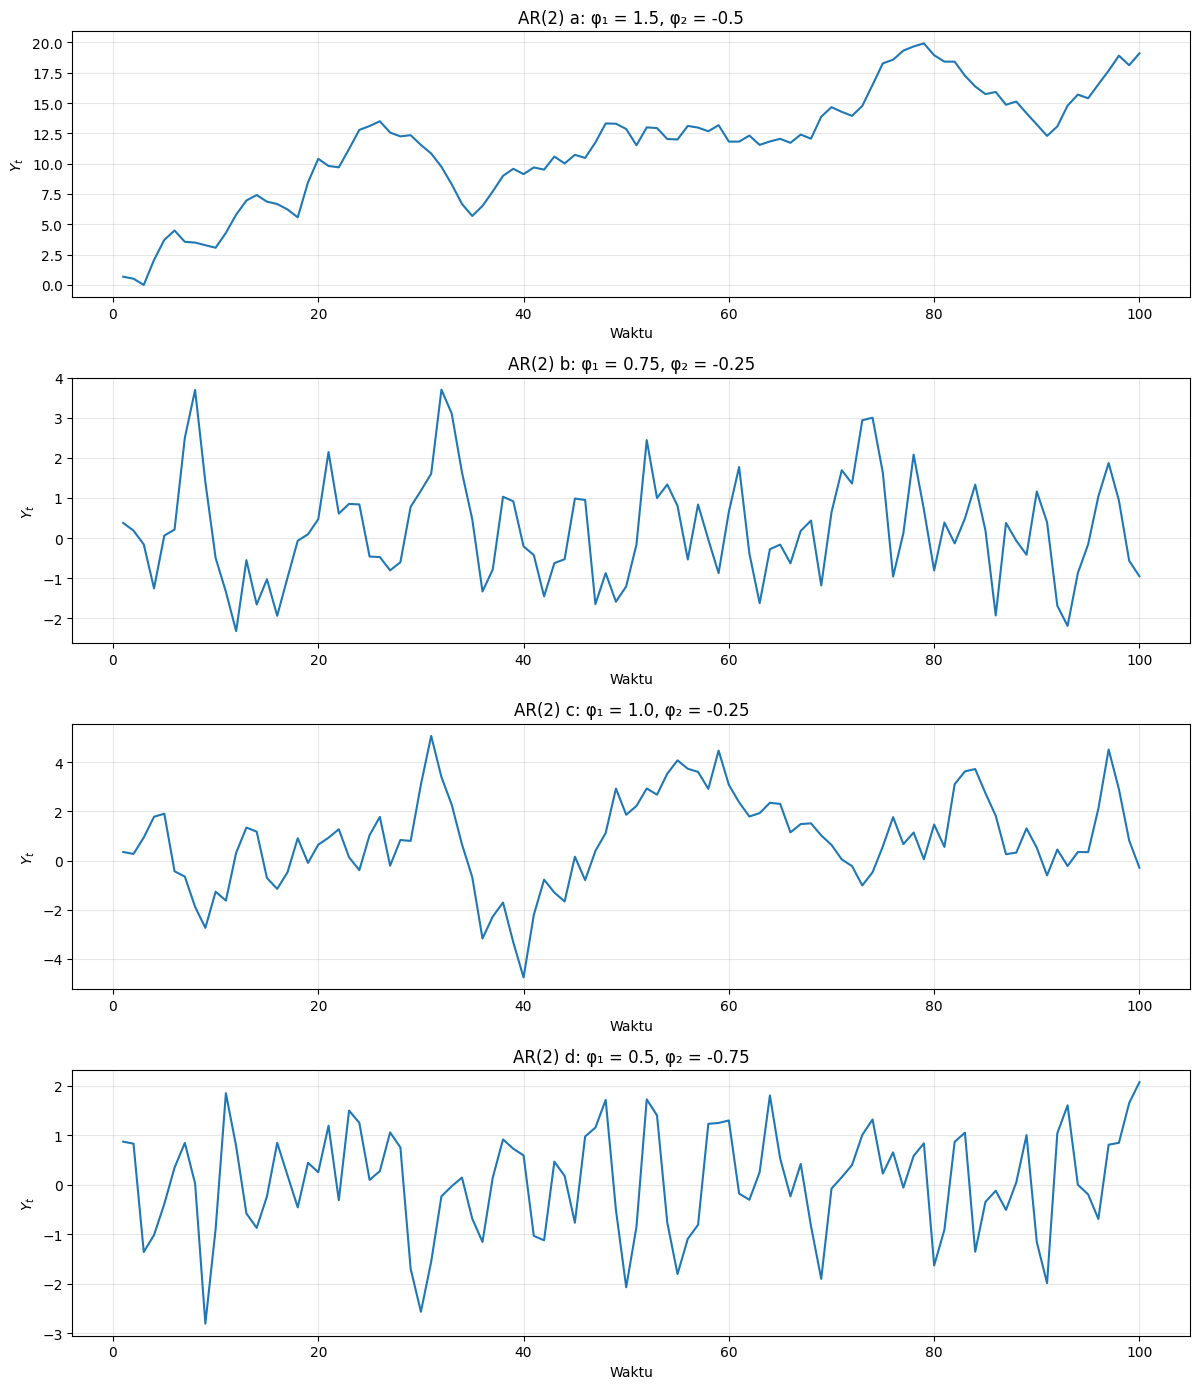

In [34]:
# ============================================================
# SIMULASI AR(2)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Fungsi simulasi AR(2)
# ============================================================

def simulate_ar2(phi1, phi2, n=100, sigma=1):
    """
    Simulasi proses AR(2) berdasarkan formula user:
        Y_t = phi1 * Y_(t-1) + phi2 * Y_(t-2) + epsilon_t
    dengan:
        Y_0, Y_1 ~ Uniform(0,1)
        epsilon_t ~ Normal(0, sigma^2)
    """
    # Initialize with two random uniform values for Y_0 and Y_1
    y = [np.random.uniform(0, 1), np.random.uniform(0, 1)]

    # Generate the rest of the series
    for _ in range(n - 2): # Loop n-2 times to get total n observations (2 initial + n-2 appended)
        # Use y[-1] for Y_(t-1) and y[-2] for Y_(t-2) for current t
        y.append(phi1 * y[-1] + phi2 * y[-2] + np.random.normal(0, sigma))

    return np.array(y)


# ============================================================
# 2. Parameter AR(2)
# ============================================================

parameters = {
    'a': (1.5, -0.5),
    'b': (0.75, -0.25),
    'c': (1.0, -0.25),
    'd': (0.5, -0.75)
}


# ============================================================
# 3. Seed agar hasil dapat direplikasi
# ============================================================

np.random.seed(120)


# ============================================================
# 4. Simulasi data
# ============================================================

series_ar2 = {}

for kode, (phi1, phi2) in parameters.items():

    series_ar2[kode] = simulate_ar2(
        phi1=phi1,
        phi2=phi2,
        n=100,
        sigma=1
    )


# ============================================================
# 5. Plot hasil simulasi
# ============================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 14)
)


for ax, (kode, (phi1, phi2)) in zip(
    axes,
    parameters.items()
):

    y = series_ar2[kode]

    ax.plot(
        range(1, 101),
        y
    )

    ax.set_title(
        f'AR(2) {kode}: '
        f'φ₁ = {phi1}, φ₂ = {phi2}'
    )

    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')

    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

11. Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 10. Berdasarkan plot ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada deret AR(2)? (Hint: Identifikasi pola nilai autokorelasi ataupun autokorelasi parsial berdasarkan nilai parameter AR.)


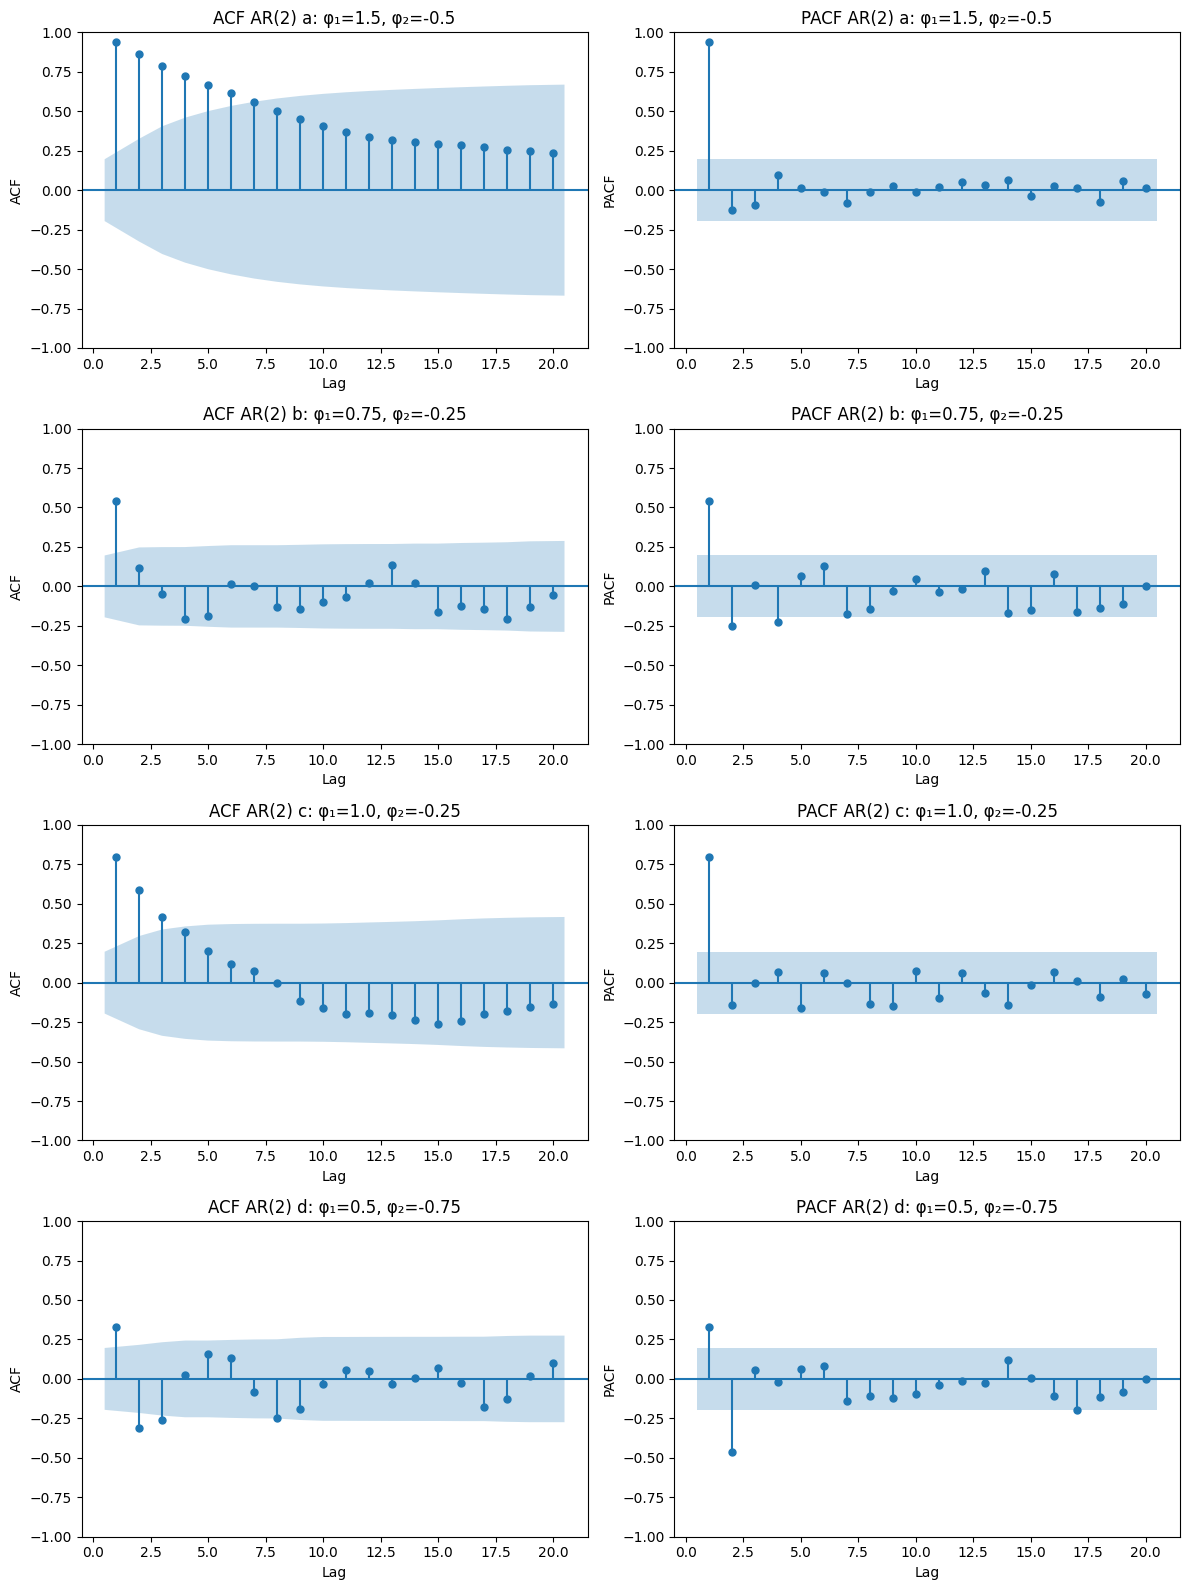

In [35]:
# ============================================================
# PLOT ACF DAN PACF AR(2)
# Menggunakan data simulasi yang sudah tersimpan
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Parameter AR(2)
parameters = {
    'a': (1.5, -0.5),
    'b': (0.75, -0.25),
    'c': (1.0, -0.25),
    'd': (0.5, -0.75)
}


# ============================================================
# Plot ACF dan PACF
# ============================================================

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

for i, (kode, (phi1, phi2)) in enumerate(parameters.items()):

    # Mengambil data simulasi yang SUDAH dibuat
    y = series_ar2[kode]

    # -----------------------------
    # ACF
    # -----------------------------
    plot_acf(
        y,
        lags=20,
        zero=False,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f'ACF AR(2) {kode}: '
        f'φ₁={phi1}, φ₂={phi2}'
    )

    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('ACF')


    # -----------------------------
    # PACF
    # -----------------------------
    plot_pacf(
        y,
        lags=20,
        zero=False,
        method='ywm',
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(
        f'PACF AR(2) {kode}: '
        f'φ₁={phi1}, φ₂={phi2}'
    )

    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('PACF')


plt.tight_layout()
plt.show()

12. Berdasarkan plot ACF dan PACF pada nomor 11, model apa yang disarankan untuk masing-masing deret? Jelaskan jawaban Anda.

Model yang sesuai yaitu:

a	1.5	-0.5 : ARIMA(1,1,0)

b	0.75	-0.25	: AR(2)

c	1.00	-0.25	: AR(2)

d	0.50	-0.75	: AR(2)


Plot ACF dan PACF pada model (a) dengan parameter phi : (1.5, -0.5)

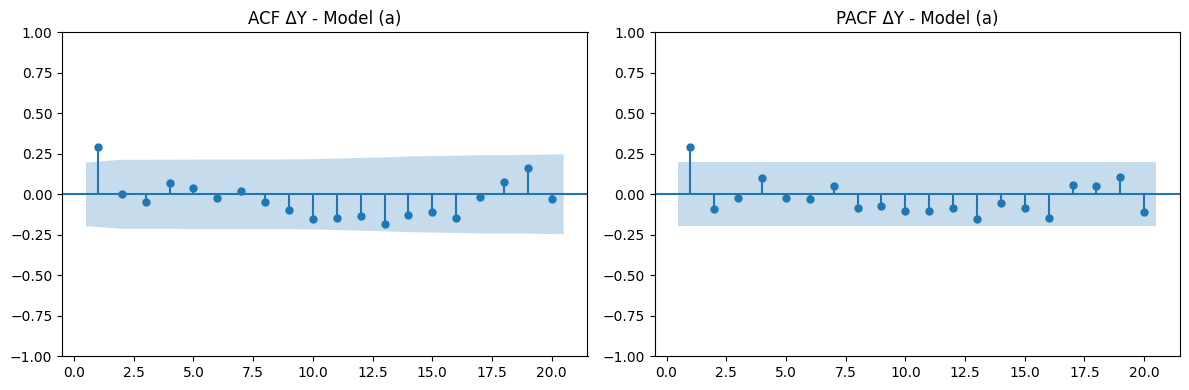

In [36]:
y_a = series_ar2['a']

# First differencing
dy_a = np.diff(y_a)

# Plot ACF dan PACF setelah differencing
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(dy_a, lags=20, zero=False, ax=axes[0])
axes[0].set_title('ACF ΔY - Model (a)')

plot_pacf(dy_a, lags=20, zero=False, method='ywm', ax=axes[1])
axes[1].set_title('PACF ΔY - Model (a)')

plt.tight_layout()
plt.show()